# MNIST Example with Restricted Boltzmann Machine

This notebook demonstrates how to use a Restricted Boltzmann Machine (RBM)
for unsupervised learning on the MNIST dataset. The RBM learns to reconstruct
handwritten digit images by discovering latent representations in the data.

**Key steps:**
1. Import required libraries
2. Define visualization helper functions
3. Load and preprocess the MNIST dataset
4. Train the RBM model
5. Visualize reconstructions and hidden layer activations

In [1]:
import sys

# Añade el directorio principal al path de búsqueda para importar módulos desde esa ubicación
sys.path.insert(0, "..")

from collections.abc import Sequence
from typing import Any
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import pyplot
import numpy as np

from restricted_boltzmann import RestrictedBoltzmann
from restricted_boltzmann.tools import RBMReportGenerator

## Helper Functions

The following helper functions provide utilities for visualizing input images,
model reconstructions, and hidden layer activations.

In [ ]:
# This example was inspired by the implementation found in:
# https://github.com/Imsanskar/Boltzman-Machine/blob/master/boltzman_machine.ipynb


def plot_model_activations(
    x_test: tf.Tensor,
    output_test: tf.Tensor,
    model: Any,
    image_width: int = 28,
    image_height: int = 28,
    grid_size: int = 5,
    output_path: str = "output.png",
) -> None:
    """Plot input images, model predictions, and hidden activations."""

    num_images = min(output_test.shape[0], grid_size**2)
    figure, axes = plt.subplots(
        grid_size,
        grid_size,
        figsize=(20, 20),
        squeeze=False,
    )

    for i, ax in enumerate(axes.flat[:num_images]):
        image = x_test[i].reshape(1, image_width, image_height)
        prediction = model.predict_proba(x_test[i].reshape(1, -1)).reshape(
            1, image_width, image_height
        )
        hidden_activation = model.get_hidden_activations(x_test[i].reshape(1, -1)).reshape(
            1, image_width, -1
        )

        image_show = tf.concat(
            [image, prediction, hidden_activation],
            axis=2,
        )

        ax.imshow(
            tf.squeeze(image_show).numpy(),
            cmap=plt.cm.RdBu,
            interpolation="nearest",
            vmin=-2.5,
            vmax=2.5,
        )
        ax.axis("off")

    for ax in axes.flat[num_images:]:
        ax.axis("off")

    figure.subplots_adjust(
        wspace=0.01,
        hspace=0,
        left=0,
        right=1,
        top=1,
        bottom=0,
    )

    figure.savefig(
        output_path,
        bbox_inches="tight",
        pad_inches=0,
    )
    plt.show()

In [3]:
def plot_multiple_images(
    images: Sequence[np.ndarray],
    n_cols: int | None = None,
) -> None:
    """Plot multiple images in a grid layout."""

    n_images = len(images)

    if n_images == 0:
        return

    n_cols = n_cols or n_images
    n_cols = min(n_cols, n_images)
    n_rows = (n_images + n_cols - 1) // n_cols

    figure, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols, n_rows),
        squeeze=False,
    )

    for index, image in enumerate(images):
        ax = axes.flat[index]
        ax.imshow(image, cmap="binary")
        ax.axis("off")

    for ax in axes.flat[n_images:]:
        ax.axis("off")

    figure.tight_layout(pad=0)
    plt.show()

## Load and Preprocess Data

Load the MNIST handwritten digits dataset, normalize pixel values to [0, 1],
and flatten each 28×28 image into a 784-dimensional vector. Non-zero pixels
are set to 1 to binarize the input for the RBM.

In [4]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255, x_test / 255
x_train, x_test = x_train.reshape([-1, 784]), x_test.reshape([-1, 784])
x_train = tf.where(x_train != 0.0, tf.ones_like(x_train, dtype="float32"), x_train).numpy()

## Visualize Training Data

Display a sample of 16 training images to inspect the input data before training.

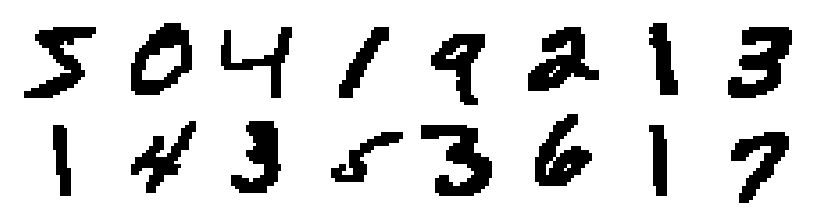

In [5]:
plot_multiple_images(x_train.reshape([-1, 28, 28])[:16, :, :], 8)

## Train the RBM Model

Create a Restricted Boltzmann Machine with 392 hidden units (one per pixel)
and train it on the MNIST training data. The model uses early stopping
with a patience of 10 epochs to prevent overfitting.

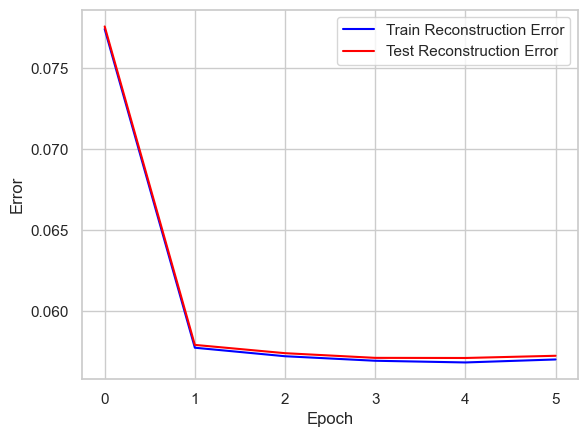

Early stopping at epoch 10


In [6]:
hidden_units = 392
visible_units = x_train.shape[1]

model = RestrictedBoltzmann()
model.train(
    x_train,
    hidden_units,
    visible_units,
    epochs=200,
    batch_size=1_000,
    early_stopping_patience=5,
    plot=True,
)

## Generate Reconstructions

Use the trained model to reconstruct the training images by passing them
through the forward (visible → hidden) and backward (hidden → visible) passes.

In [7]:
output_test = model.predict(x_train)
output_test = output_test.reshape([-1, 28, 28])

## Visualize Reconstructions

Display the reconstructed images to evaluate the quality of the learned
representations. Compare them with the original training samples shown earlier.

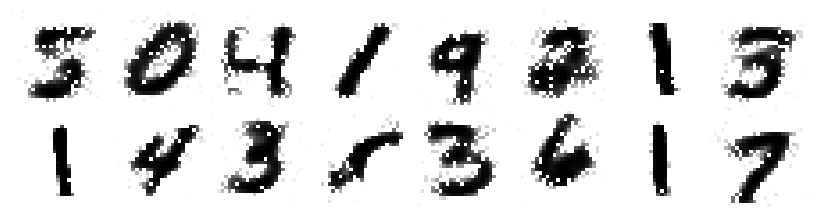

In [8]:
plot_multiple_images(output_test[:16, :, :], 8)

## Visualize Model Activations

For each test image, plot the original input, the model reconstruction,
and the hidden layer activations side by side. This allows inspection of
which features the RBM has learned to represent.

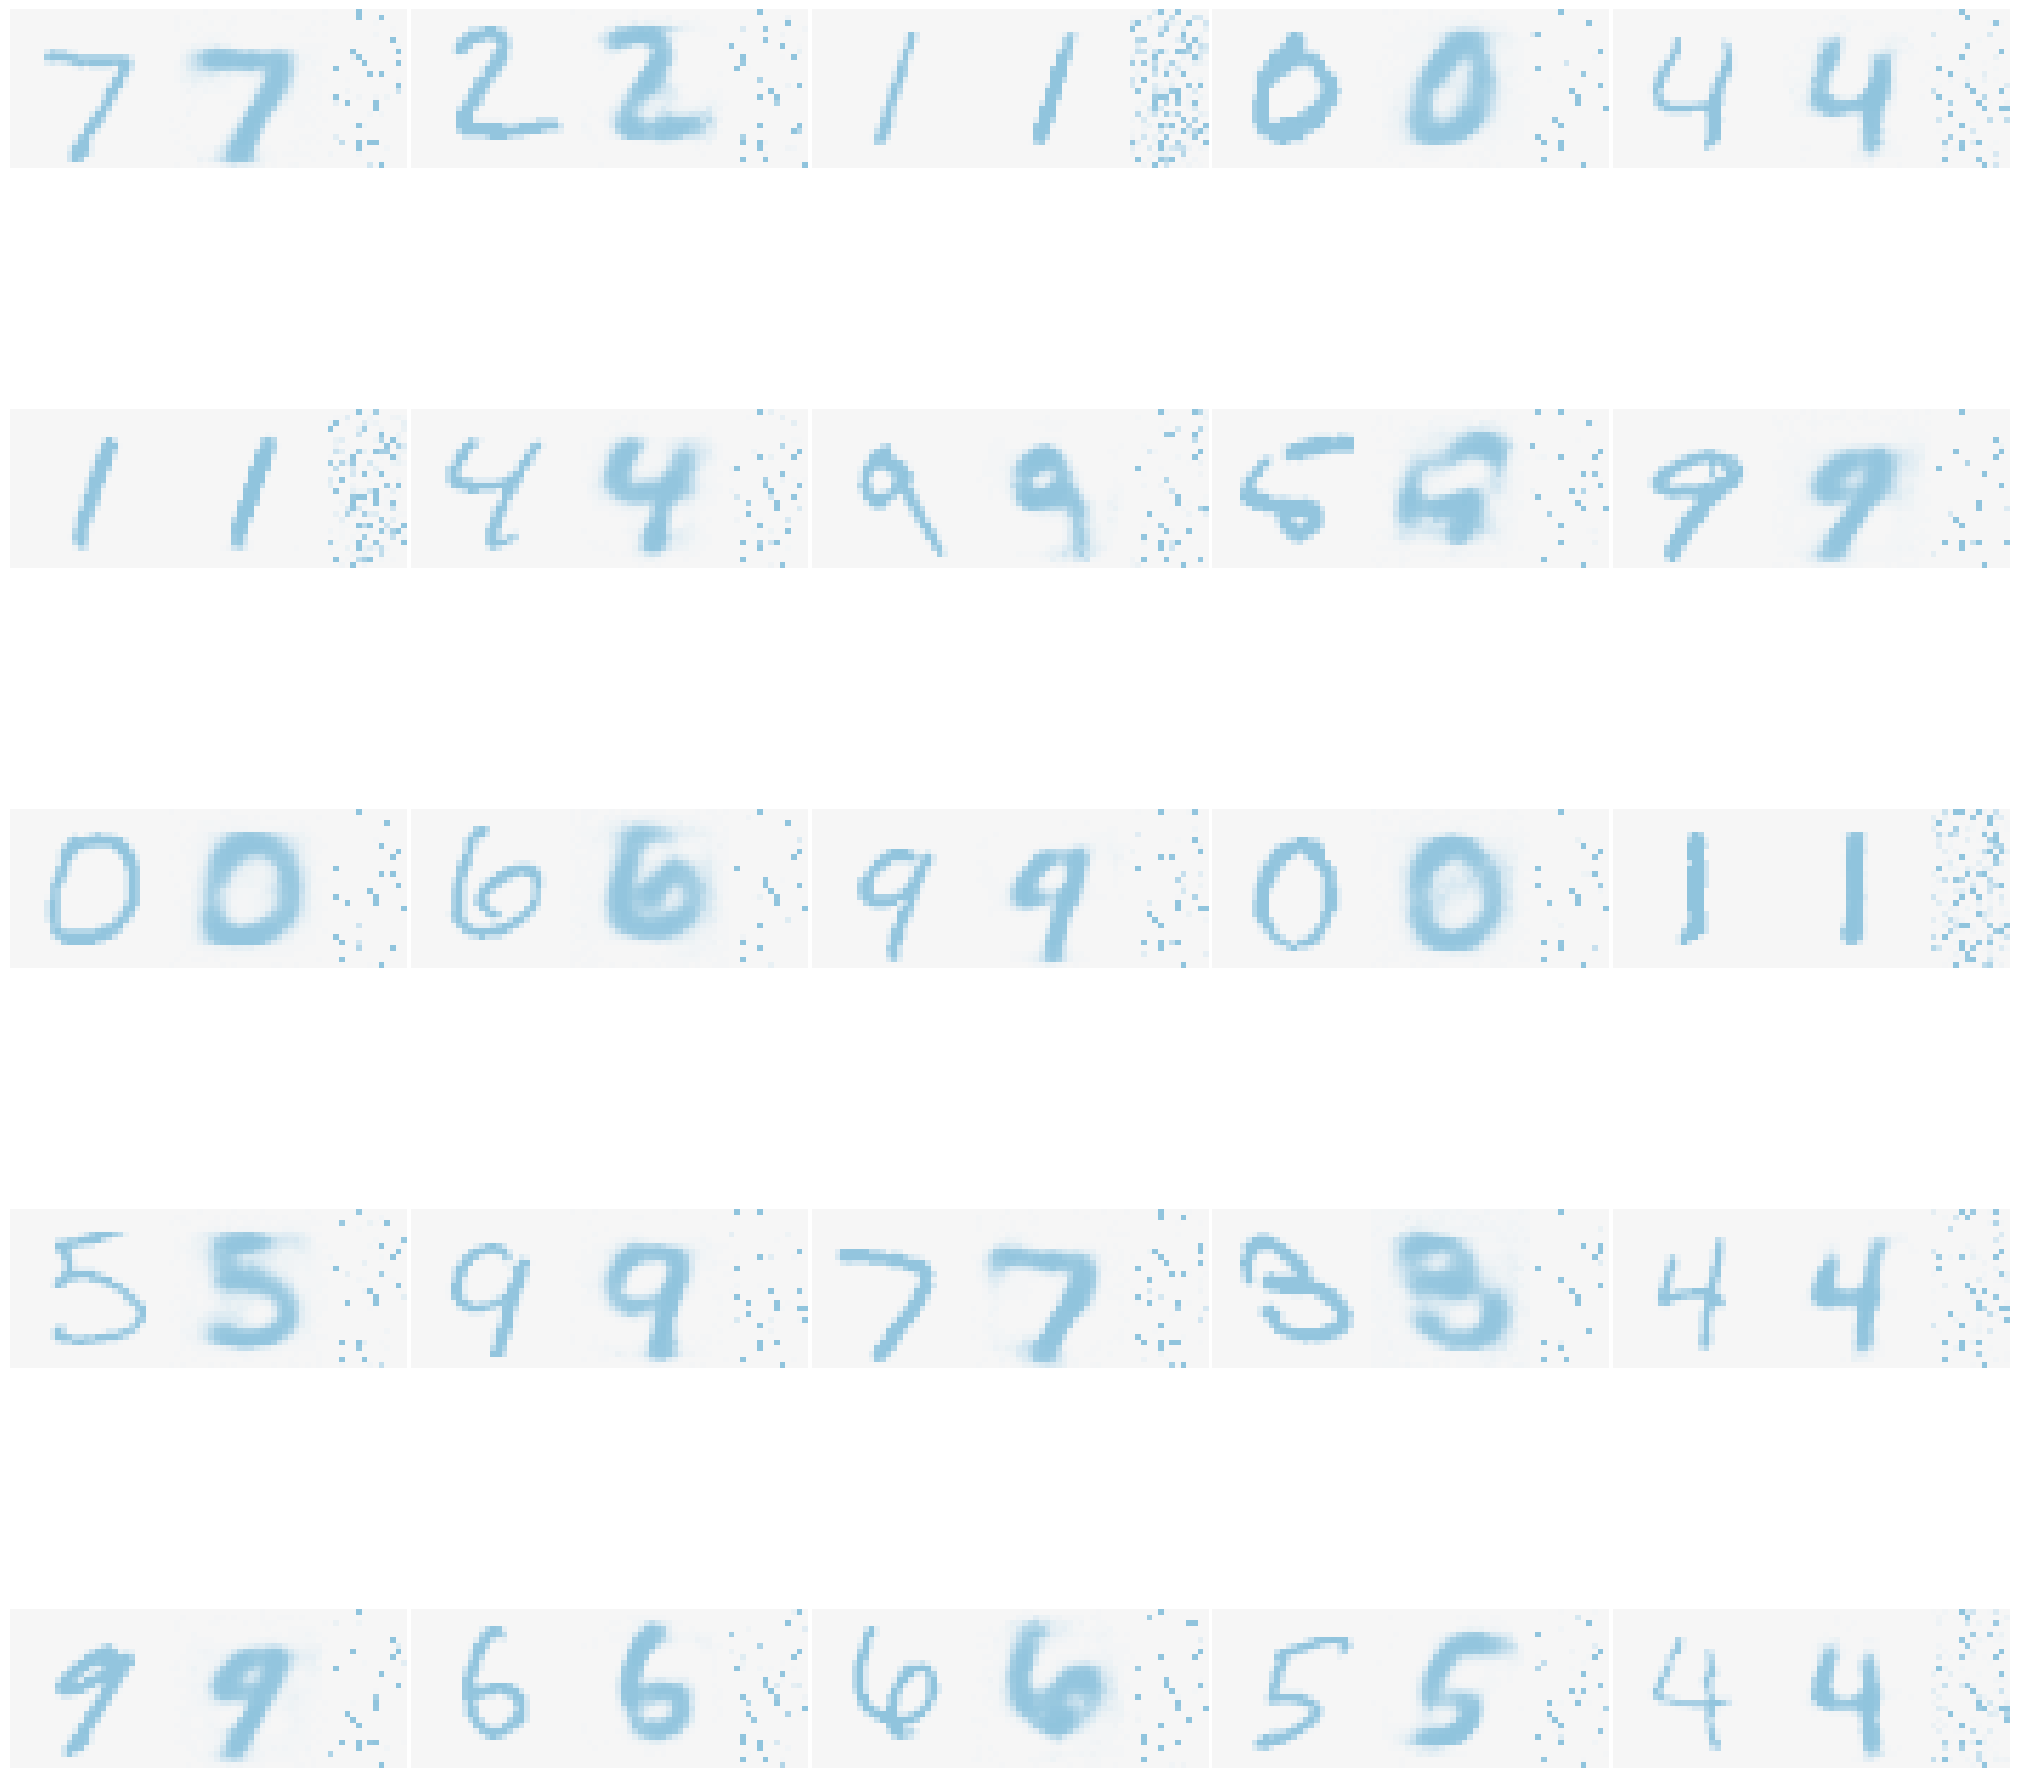

In [9]:
plot_model_activations(x_test, output_test, model)